# Task 1 — Data Loading, Merging & Deep Exploration


In [2]:
import pandas as pd
import numpy as np

In [3]:
data=pd.read_csv("train.csv")

In [4]:
df=data.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
#correct all datatypes
#order Date and Ship date to datetime
#using coerce will make date NaT if date not in correct format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [7]:
#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

# Year
df["Year"] = df["Order Date"].dt.year

# Month
df["Month"] = df["Order Date"].dt.month

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Day of Week (0 = Monday, 6 = Sunday)
df["DayOfWeek"] = df["Order Date"].dt.dayofweek

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter


In [8]:
#as there is no inbuilt fn for season we are craeting a fn for it
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [9]:
#remove duplicates
df.nunique()
df = df.drop_duplicates()

In [10]:
#find missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
DayOfWeek         0
Quarter           0
Season            0
dtype: int64

In [11]:
#only postal code has missing value and we can drop postal code as it is redundant col
df.drop(["Postal Code"], axis=1, inplace=True)

In [12]:
#dropping unimportant features
df.drop(["Row ID"], axis=1, inplace=True)
df.drop(["Customer Name"], axis=1, inplace=True)
df.drop(["Customer ID"], axis=1, inplace=True)

#only US data it is (1 country for all)
df.drop(["Country"], axis=1, inplace=True)

In [13]:
#to find out is product id for same product name is same or not
product=df[df["Product Name"]=="Bush Somerset Collection Bookcase"]
product.nunique()

Order ID        4
Order Date      4
Ship Date       4
Ship Mode       3
Segment         1
City            4
State           4
Region          3
Product ID      1
Category        1
Sub-Category    1
Product Name    1
Sales           4
Year            2
Month           4
Week            4
DayOfWeek       4
Quarter         3
Season          3
dtype: int64

In [14]:
#Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
weekly_sales = df.groupby(
    [pd.Grouper(key="Order Date", freq="W"), "Category", "Sub-Category"]
)["Sales"].sum().reset_index()

monthly_sales = df.groupby(
    [pd.Grouper(key="Order Date", freq="ME"), "Category", "Sub-Category"]
)["Sales"].sum().reset_index()

print(weekly_sales.head())
print(" ")
print(monthly_sales.head())

  Order Date         Category Sub-Category     Sales
0 2015-01-04  Office Supplies      Binders     3.540
1 2015-01-04  Office Supplies       Labels    11.784
2 2015-01-04  Office Supplies        Paper    16.448
3 2015-01-04  Office Supplies      Storage   272.736
4 2015-01-11        Furniture       Chairs  2573.820
 
  Order Date         Category Sub-Category     Sales
0 2015-01-31        Furniture    Bookcases  1010.055
1 2015-01-31        Furniture       Chairs  4187.700
2 2015-01-31        Furniture  Furnishings   686.522
3 2015-01-31        Furniture       Tables   333.000
4 2015-01-31  Office Supplies   Appliances   312.580


In [15]:
monthly_sales

,Order Date,Category,Sub-Category,Sales
0,2015-01-31,Furniture,Bookcases,1010.055
1,2015-01-31,Furniture,Chairs,4187.700
2,2015-01-31,Furniture,Furnishings,686.522
3,2015-01-31,Furniture,Tables,333.000
4,2015-01-31,Office Supplies,Appliances,312.580
...,...,...,...,...
777,2018-12-31,Office Supplies,Supplies,2566.338
778,2018-12-31,Technology,Accessories,4988.996
779,2018-12-31,Technology,Copiers,6679.888
780,2018-12-31,Technology,Machines,1248.970


## Answer these questions in your notebook with data to back each one:

#### Which product category generates the highest total revenue?
Highest Revenue is made by Technology cateory with approx of 820000 total sales.
#### Which region has the most consistent sales growth over 4 years?
through the comparison of yearly sales region wise we got that East region's sales are the most consistent over 4 years.
#### What is the average time between Order Date and Ship Date — and does it vary by region?
The average time is approx 3.9 and yes it varies by region in this order Central > South > West > East.
#### Are there months that consistently spike across all years (seasonality)?
Yes there is seasonality in the sales as, Sales consistently spike during November and December across all years, indicating a strong increase in demand during the festive or holiday season and in moth of jan that is after holiday break there is decline in sales and in september a sudden spike observed in sales.

In [16]:
#Which product category generates the highest total revenue?¶

total_revenue= df.groupby(
   ["Category"]
)["Sales"].sum().reset_index()

total_revenue.sort_values(by="Sales" , ascending=False,inplace=True)

print(f"Highest revenue is made by {total_revenue.iloc[0,0] } with {total_revenue.iloc[0,1]} total sales")
total_revenue

Highest revenue is made by Technology with 827455.873 total sales


,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


In [17]:
import matplotlib.pyplot as plt

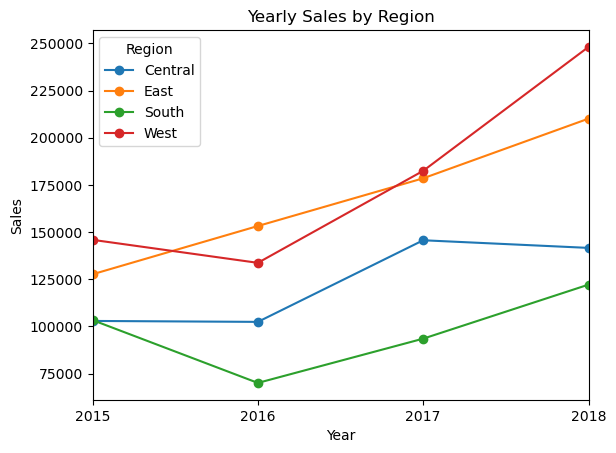

In [18]:
#Which region has the most consistent sales growth over 4 years?
region_growth = df.groupby(
    [pd.Grouper(key="Order Date", freq="YE"), "Region"]
)["Sales"].sum().reset_index()

pivot_df = region_growth.pivot(index="Order Date", 
                               columns="Region", 
                               values="Sales")

pivot_df.plot(marker='o')

plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Yearly Sales by Region")
plt.legend(title="Region")

plt.show()

In [19]:
#What is the average time between Order Date and Ship Date — and does it vary by region?
df["Delivery Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

avg_delivery = df["Delivery Days"].mean()
print("Average Delivery Time:", avg_delivery)

region_delivery = df.groupby("Region")["Delivery Days"].mean()

print(region_delivery)

Average Delivery Time: 3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Delivery Days, dtype: float64


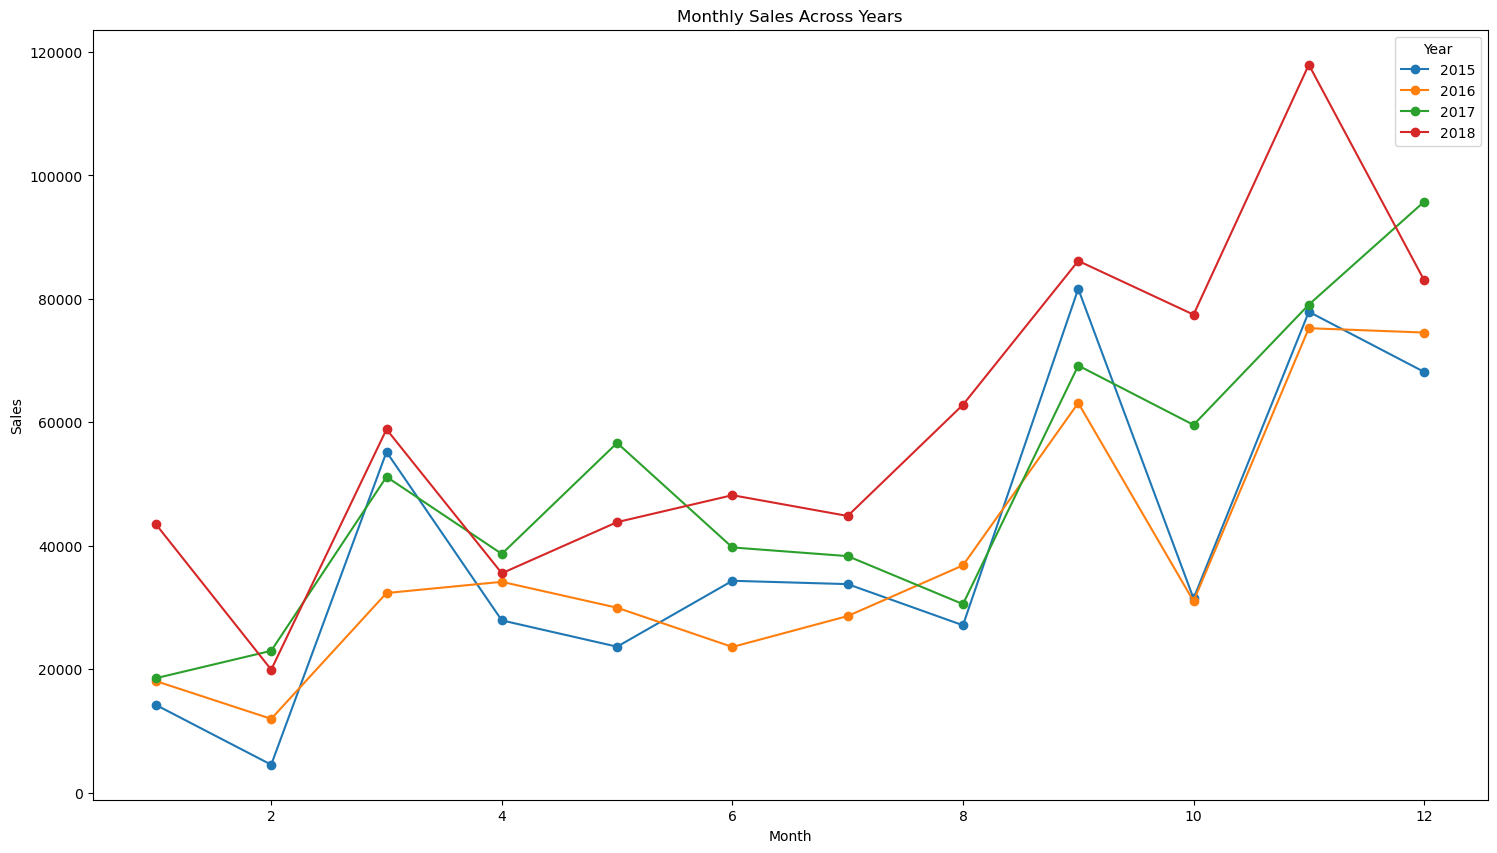

In [20]:
#Are there months that consistently spike across all years (seasonality)?
monthly_pattern = df.groupby(["Year", "Month"])["Sales"].sum().unstack()

monthly_pattern.T.plot(marker='o', figsize=(18,10))

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Across Years")
plt.show()


In [21]:
df.head(5)

,Order ID,Order Date,Ship Date,Ship Mode,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season,Delivery Days
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn,3
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn,3
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Monsoon,4
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn,7
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn,7


# Task 2 — Time Series Analysis & Decomposition


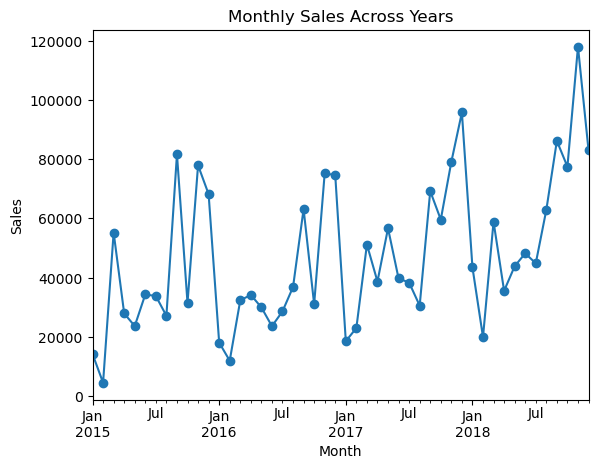

In [22]:
#Plot the overall monthly sales trend across all 4 years
#as already done

monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()
monthly_sales.T.plot(marker='o')

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Across Years")
plt.show()

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt

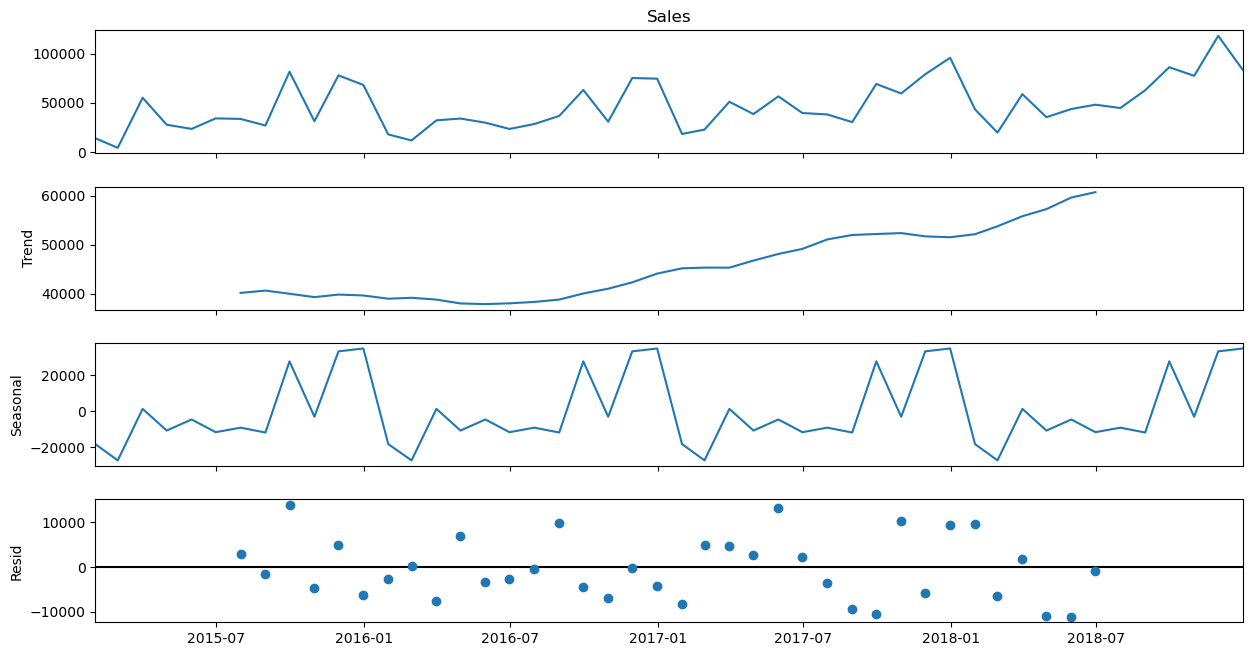

In [24]:
#Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
#Trend component
#Seasonal component
#Residual/noise component

result = seasonal_decompose(monthly_sales, model='additive')

fig = result.plot()         
fig.set_size_inches(14, 7)  

plt.show()

In [25]:
#Check for stationarity using the Augmented Dickey-Fuller (ADF) Test 
result = adfuller(monthly_sales)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623


# Task 3 — Sales Forecasting using 3 Different Models

## Model 1 — SARIMA (Statistical Model)


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [27]:
# Fit model
model = SARIMAX(monthly_sales,
                order=(1,1,1),              # (p,d,q)
                seasonal_order=(1,1,1,12))  # (P,D,Q,m)

sarima_model = model.fit()

# Forecast next 3 months
sarima_forecast = sarima_model.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


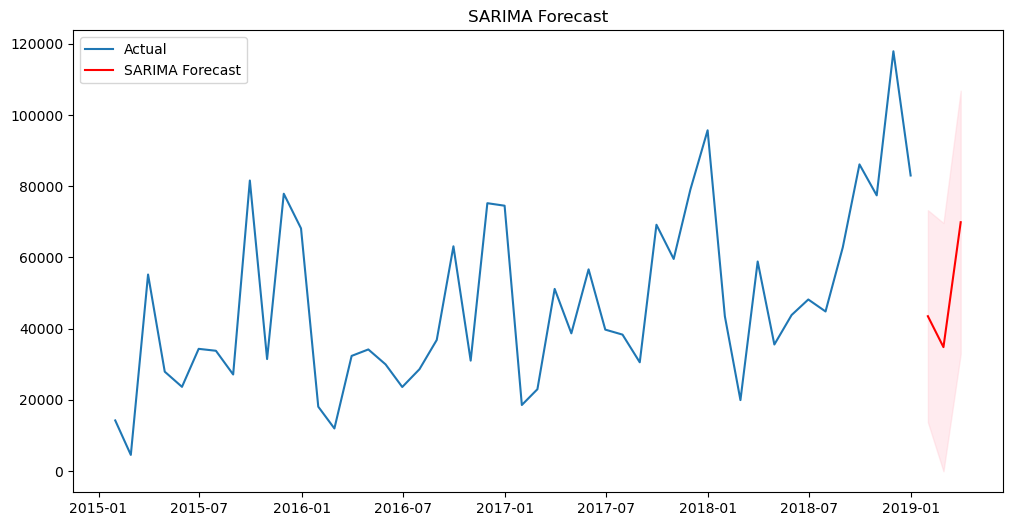

In [28]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label="Actual")
plt.plot(sarima_pred, label="SARIMA Forecast", color='red')
plt.fill_between(sarima_ci.index,
                 sarima_ci.iloc[:,0],
                 sarima_ci.iloc[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("SARIMA Forecast")
plt.show()

## Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


In [29]:
from prophet import Prophet

In [30]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']

In [31]:
model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=3, freq='ME')
forecast = model.predict(future)

16:46:38 - cmdstanpy - INFO - Chain [1] start processing
16:46:39 - cmdstanpy - INFO - Chain [1] done processing


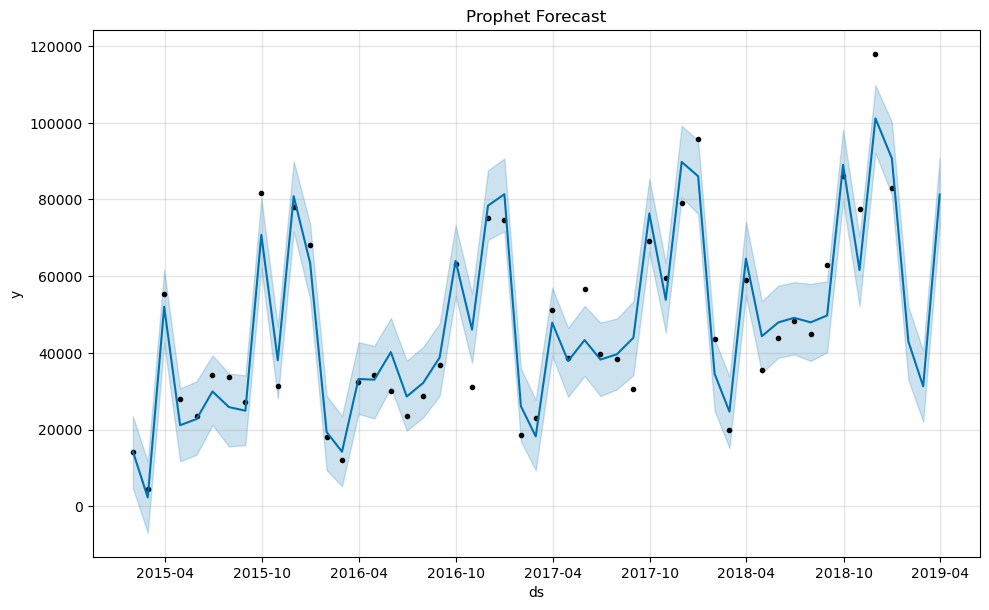

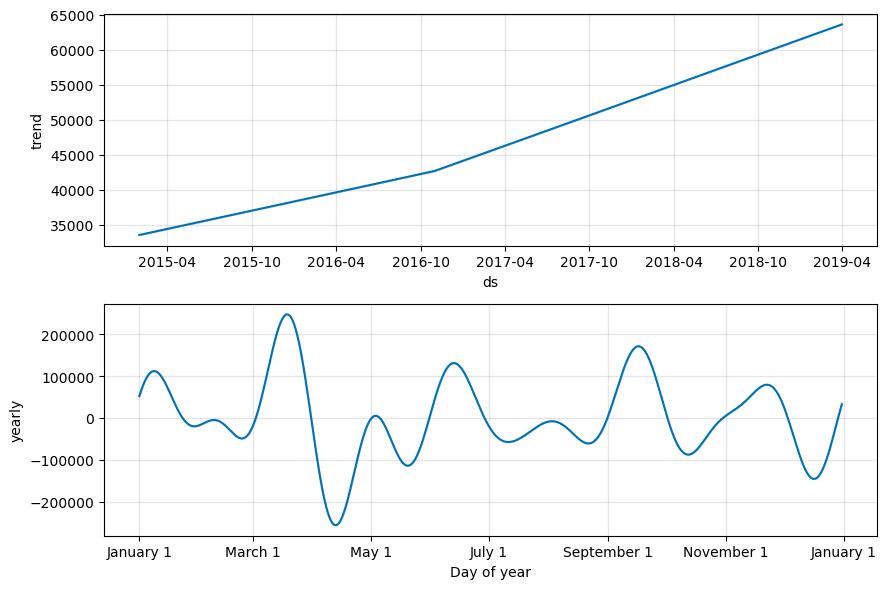

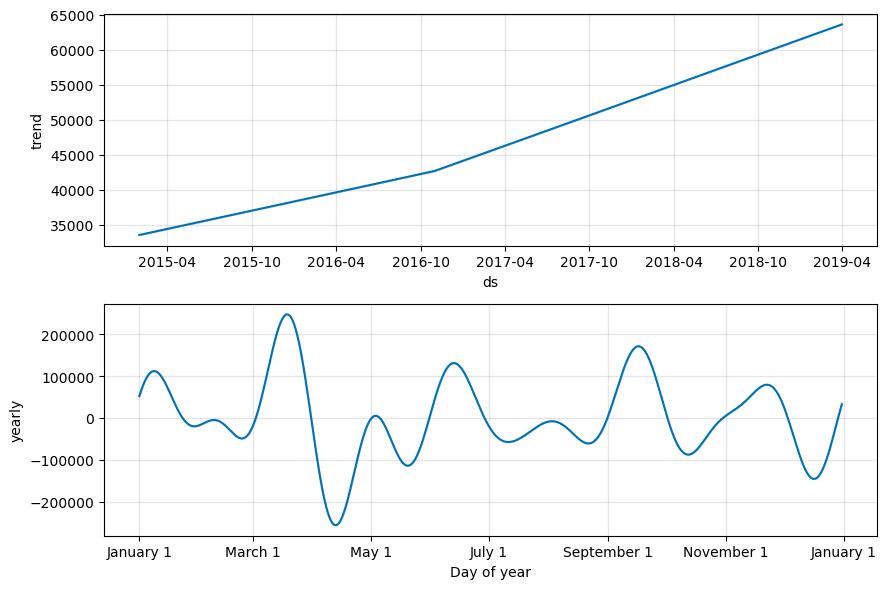

In [32]:
model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

model.plot_components(forecast)

## Model 3 — XGBoost for Time Series (ML-based Approach)

In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
df_ml = monthly_sales.to_frame(name='Sales')

df_ml['lag1'] = df_ml['Sales'].shift(1)
df_ml['lag2'] = df_ml['Sales'].shift(2)
df_ml['lag3'] = df_ml['Sales'].shift(3)

df_ml['rolling_mean'] = df_ml['Sales'].rolling(3).mean()

df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter

df_ml.dropna(inplace=True)

C:\Users\Tanya\AppData\Local\Temp\ipykernel_7912\1039503117.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=monthly_sales.index[-1], periods=4, freq='M')[1:]


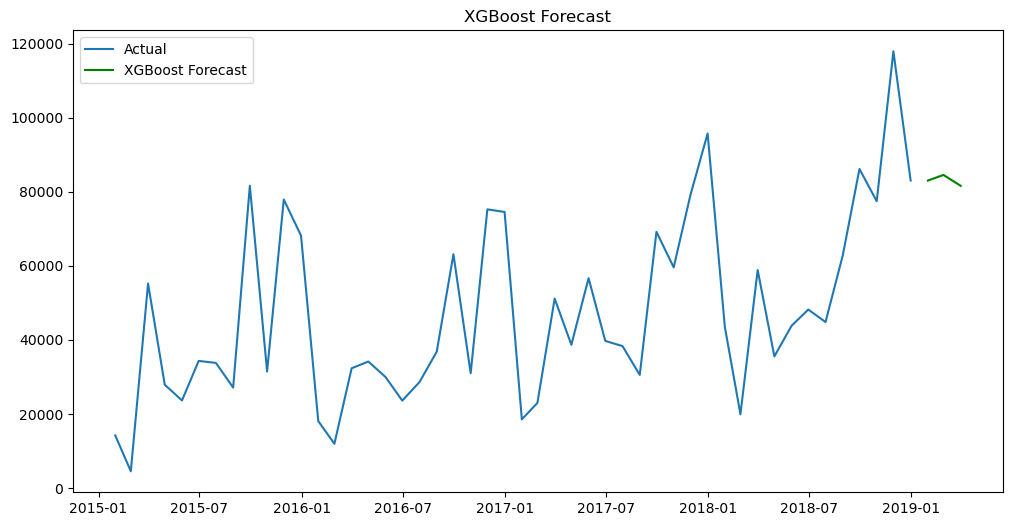

In [35]:

X = df_ml.drop('Sales', axis=1)
y = df_ml['Sales']

model = XGBRegressor()
model.fit(X, y)

last_data = df_ml.iloc[-1:].copy()

predictions = []

for i in range(3):
    pred = model.predict(last_data.drop('Sales', axis=1))[0]
    predictions.append(pred)
    
    # update lags
    last_data['lag3'] = last_data['lag2']
    last_data['lag2'] = last_data['lag1']
    last_data['lag1'] = pred
    last_data['Sales'] = pred

future_index = pd.date_range(start=monthly_sales.index[-1], periods=4, freq='M')[1:]

plt.figure(figsize=(12,6))
plt.plot(monthly_sales, label='Actual')
plt.plot(future_index, predictions, label='XGBoost Forecast', color='green')

plt.legend()
plt.title("XGBoost Forecast")
plt.show()

## Model Comparison Table (Required)


In [36]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [37]:
sarima_model = SARIMAX(train,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12)).fit()

sarima_pred = sarima_model.forecast(steps=3)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [38]:
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=3, freq='ME')
forecast = model.predict(future)

prophet_pred = forecast.tail(3)['yhat'].values

16:46:45 - cmdstanpy - INFO - Chain [1] start processing
16:46:46 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
# Recreate features on full data first
df_ml = monthly_sales.to_frame(name='Sales')

df_ml['lag1'] = df_ml['Sales'].shift(1)
df_ml['lag2'] = df_ml['Sales'].shift(2)
df_ml['lag3'] = df_ml['Sales'].shift(3)
df_ml['rolling_mean'] = df_ml['Sales'].rolling(3).mean()
df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter

df_ml.dropna(inplace=True)

# Split
train_ml = df_ml[:-3]
test_ml = df_ml[-3:]

X_train = train_ml.drop('Sales', axis=1)
y_train = train_ml['Sales']

X_test = test_ml.drop('Sales', axis=1)
y_test = test_ml['Sales']

model = XGBRegressor()
model.fit(X_train, y_train)

xgb_pred = model.predict(X_test)

In [40]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted)/actual))*100
    return mae, rmse, mape

In [41]:
sarima_mae, sarima_rmse, sarima_mape = evaluate(test, sarima_pred)

prophet_mae, prophet_rmse, prophet_mape = evaluate(test, prophet_pred)

xgb_mae, xgb_rmse, xgb_mape = evaluate(y_test, xgb_pred)

In [42]:

results = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape],
    "Month1": [sarima_pred.iloc[0], prophet_pred[0], xgb_pred[0]],
    "Month2": [sarima_pred.iloc[1], prophet_pred[1], xgb_pred[1]],
    "Month3": [sarima_pred.iloc[2], prophet_pred[2], xgb_pred[2]]
})

print(results)

     Model           MAE          RMSE       MAPE        Month1        Month2  \
0   SARIMA  18031.404654  19009.182054  18.966498  66177.602485  92049.249693   
1  Prophet  20250.794413  22318.411333  21.864628  51318.943858  90325.654784   
2  XGBoost  14443.456458  17069.090751  14.447258  87142.953125  90766.710938   

         Month3  
0  99965.168738  
1  90041.084479  
2  89494.492188  


In [43]:
results.sort_values(by="RMSE")

,Model,MAE,RMSE,MAPE,Month1,Month2,Month3
2,XGBoost,14443.456458,17069.090751,14.447258,87142.953125,90766.710938,89494.492188
0,SARIMA,18031.404654,19009.182054,18.966498,66177.602485,92049.249693,99965.168738
1,Prophet,20250.794413,22318.411333,21.864628,51318.943858,90325.654784,90041.084479


# Task 4 — Product Category & Region Level Forecasting

In [44]:
def get_monthly_sales(data):
    monthly = data.resample('ME', on='Order Date')['Sales'].sum()
    monthly = monthly.asfreq('ME')
    return monthly

def xgb_forecast(series, steps=3):

    df_ml = series.to_frame(name='Sales')

    # Features
    df_ml['lag1'] = df_ml['Sales'].shift(1)
    df_ml['lag2'] = df_ml['Sales'].shift(2)
    df_ml['lag3'] = df_ml['Sales'].shift(3)
    df_ml['rolling_mean'] = df_ml['Sales'].rolling(3).mean()
    df_ml['month'] = df_ml.index.month
    df_ml['quarter'] = df_ml.index.quarter

    df_ml.dropna(inplace=True)

    # Train
    X = df_ml.drop('Sales', axis=1)
    y = df_ml['Sales']

    model = XGBRegressor(n_estimators=100, learning_rate=0.1)
    model.fit(X, y)

    # Forecast
    last_data = df_ml.iloc[-1:].copy()
    preds = []

    for i in range(steps):
        pred = model.predict(last_data.drop('Sales', axis=1))[0]
        preds.append(pred)

        # update lags
        last_data['lag3'] = last_data['lag2']
        last_data['lag2'] = last_data['lag1']
        last_data['lag1'] = pred
        last_data['Sales'] = pred

    return preds



In [45]:
# Category-wise
furniture = df[df['Category'] == 'Furniture']
technology = df[df['Category'] == 'Technology']
office = df[df['Category'] == 'Office Supplies']

# Region-wise
west = df[df['Region'] == 'West']
east = df[df['Region'] == 'East']

In [46]:
furniture_m = get_monthly_sales(furniture)
technology_m = get_monthly_sales(technology)
office_m = get_monthly_sales(office)

west_m = get_monthly_sales(west)
east_m = get_monthly_sales(east)


In [47]:
furniture_pred = xgb_forecast(furniture_m)
technology_pred = xgb_forecast(technology_m)
office_pred = xgb_forecast(office_m)

west_pred = xgb_forecast(west_m)
east_pred = xgb_forecast(east_m)

future_index = pd.date_range(start=monthly_sales.index[-1], periods=4, freq='ME')[1:]

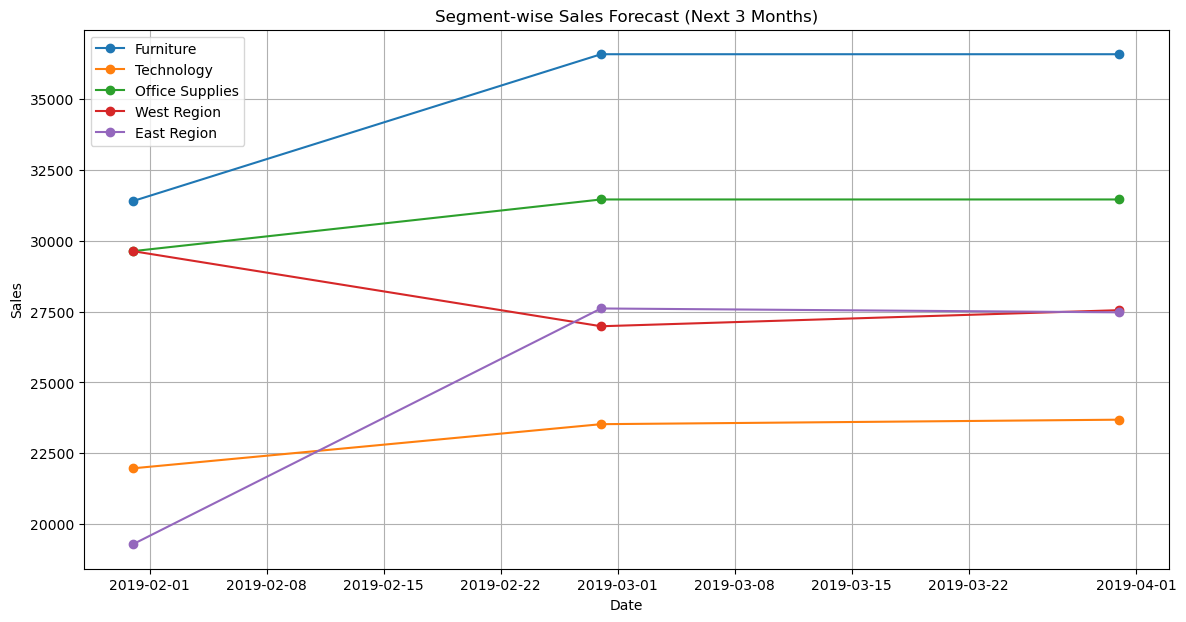

In [48]:
plt.figure(figsize=(14,7))

plt.plot(future_index, furniture_pred, marker='o', label='Furniture')
plt.plot(future_index, technology_pred, marker='o', label='Technology')
plt.plot(future_index, office_pred, marker='o', label='Office Supplies')
plt.plot(future_index, west_pred, marker='o', label='West Region')
plt.plot(future_index, east_pred, marker='o', label='East Region')

plt.title("Segment-wise Sales Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

In [49]:
def growth(pred):
    return pred[-1] - pred[0]

growths = {
    "Furniture": growth(furniture_pred),
    "Technology": growth(technology_pred),
    "Office Supplies": growth(office_pred),
    "West Region": growth(west_pred),
    "East Region": growth(east_pred)
}

print("Growth by segment:\n")
for k, v in growths.items():
    print(f"{k}: {v:.2f}")

# Find best
best_segment = max(growths, key=growths.get)

print("\n Strongest Growth shown in this Segment according to the model:", best_segment)

Growth by segment:

Furniture: 5182.68
Technology: 1716.70
Office Supplies: 1824.13
West Region: -2082.71
East Region: 8184.65

 Strongest Growth shown in this Segment according to the model: East Region


# Task 5 — Anomaly Detection in Sales Data

## ISOLATION FOREST

In [50]:
from sklearn.ensemble import IsolationForest

In [51]:
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum()

# Convert to DataFrame
df_weekly = weekly_sales.to_frame(name='Sales')

# Train model
iso = IsolationForest(contamination=0.05, random_state=42)
df_weekly['anomaly_if'] = iso.fit_predict(df_weekly[['Sales']])

# Convert labels (-1 = anomaly)
df_weekly['anomaly_if'] = df_weekly['anomaly_if'].apply(lambda x: 1 if x == -1 else 0)

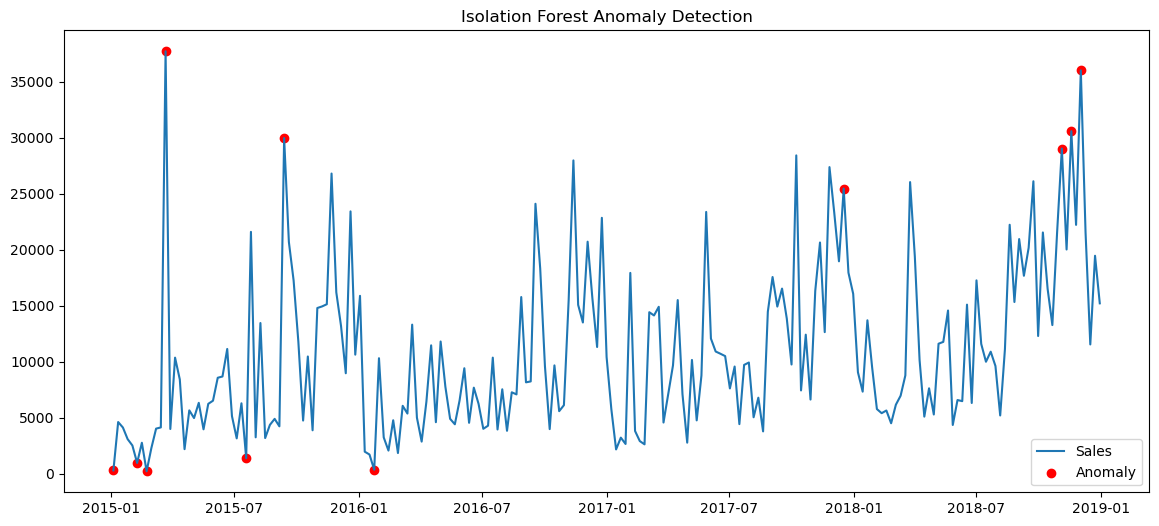

In [52]:
plt.figure(figsize=(14,6))

plt.plot(df_weekly.index, df_weekly['Sales'], label='Sales')

# Highlight anomalies
anomalies = df_weekly[df_weekly['anomaly_if'] == 1]
plt.scatter(anomalies.index, anomalies['Sales'], color='red', label='Anomaly')

plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()

## Z-SCORE (ROLLING)

In [53]:
# Rolling stats (increase window)
window_size = 8

df_weekly['rolling_mean'] = df_weekly['Sales'].rolling(window_size).mean()
df_weekly['rolling_std'] = df_weekly['Sales'].rolling(window_size).std()

# Z-score
df_weekly['z_score'] = (
    (df_weekly['Sales'] - df_weekly['rolling_mean']) / df_weekly['rolling_std']
)

# Handle NaN values
df_weekly['z_score'] = df_weekly['z_score'].fillna(0)

# ✅ FIX: reduce threshold
df_weekly['anomaly_z'] = df_weekly['z_score'].apply(
    lambda x: 1 if abs(x) > 2 else 0
)

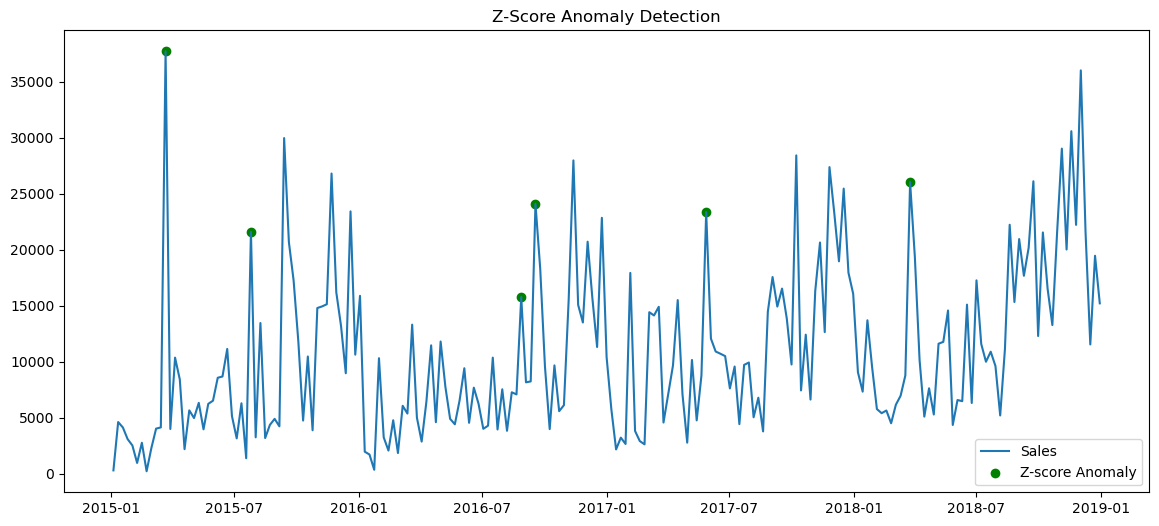

In [54]:
plt.figure(figsize=(14,6))

plt.plot(df_weekly.index, df_weekly['Sales'], label='Sales')

anomalies_z = df_weekly[df_weekly['anomaly_z'] == 1]

plt.scatter(anomalies_z.index, anomalies_z['Sales'], 
            color='green', label='Z-score Anomaly')

plt.legend()
plt.title("Z-Score Anomaly Detection")
plt.show()

# TASK 6 — PRODUCT SEGMENTATION (CLUSTERING)

In [55]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [56]:
# Monthly sales per sub-category
monthly = df.resample('ME', on='Order Date').agg({
    'Sales': 'sum',
    'Sub-Category': 'first'
})

# Better approach
subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()

In [57]:
features = []

for sub in subcat['Sub-Category'].unique():
    temp = subcat[subcat['Sub-Category'] == sub]

    total_sales = temp['Sales'].sum()
    growth = (temp['Sales'].iloc[-1] - temp['Sales'].iloc[0]) / temp['Sales'].iloc[0]
    volatility = temp['Sales'].std()
    avg_order = temp['Sales'].mean()

    features.append([sub, total_sales, growth, volatility, avg_order])

df_cluster = pd.DataFrame(features, columns=[
    'Sub-Category', 'TotalSales', 'Growth', 'Volatility', 'AvgOrder'
])

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
X = df_cluster.drop('Sub-Category', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

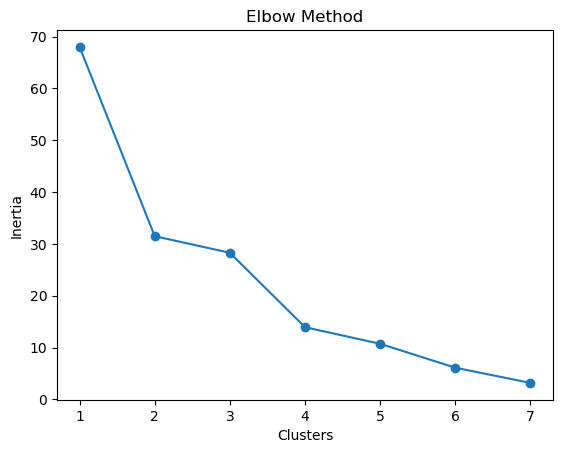

In [60]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,8), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


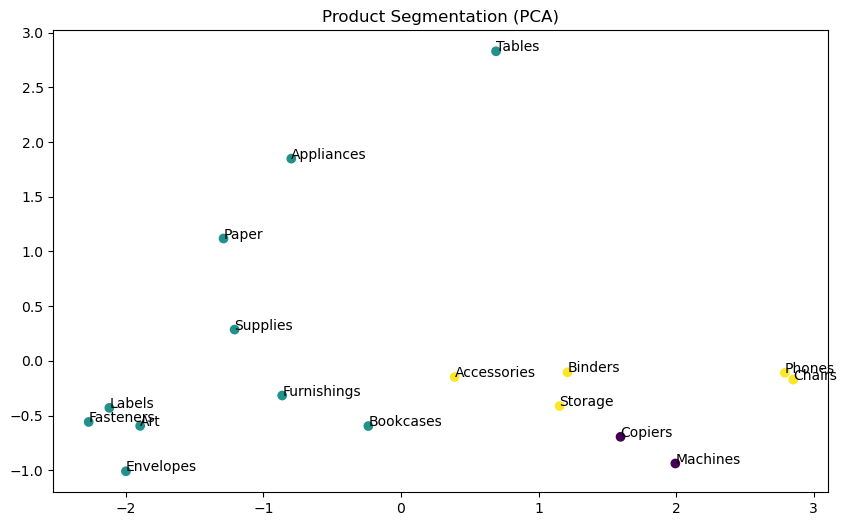

In [62]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_cluster['Cluster'])

for i, txt in enumerate(df_cluster['Sub-Category']):
    plt.annotate(txt, (X_pca[i,0], X_pca[i,1]))

plt.title("Product Segmentation (PCA)")
plt.show()

# Task 7 — Deployment: Interactive Dashboard using Streamlit

In [64]:
# ================================
# FINAL EXPORT CELL FOR STREAMLIT
# ================================

import joblib
import os

print("Starting export process...")

# 1. Save BEST MODEL (XGBoost)
try:
    joblib.dump(model, "model.pkl")
    print("✅ model.pkl saved")
except Exception as e:
    print("❌ Error saving model:", e)


# 2. Save SCALER (if used)
try:
    if 'scaler' in globals():
        joblib.dump(scaler, "scaler.pkl")
        print("✅ scaler.pkl saved")
    else:
        print("⚠️ scaler not found, skipped")
except Exception as e:
    print("❌ Error saving scaler:", e)


# 3. Save PCA (if used)
try:
    if 'pca' in globals():
        joblib.dump(pca, "pca.pkl")
        print("✅ pca.pkl saved")
    else:
        print("⚠️ PCA not used, skipped")
except Exception as e:
    print("❌ Error saving PCA:", e)


# 4. Save KMeans (if used)
try:
    if 'kmeans' in globals():
        joblib.dump(kmeans, "kmeans.pkl")
        print("✅ kmeans.pkl saved")
    else:
        print("⚠️ KMeans not used, skipped")
except Exception as e:
    print("❌ Error saving KMeans:", e)


# 5. Save FEATURE COLUMNS (CRITICAL)
try:
    joblib.dump(X.columns.tolist(), "columns.pkl")
    print("✅ columns.pkl saved")
except Exception as e:
    print("❌ Error saving columns:", e)


# 6. Save SAMPLE INPUT (for testing in app)
try:
    sample_input = X.iloc[:5]
    sample_input.to_csv("sample_input.csv", index=False)
    print("✅ sample_input.csv saved")
except Exception as e:
    print("❌ Error saving sample input:", e)


# 7. Save FINAL PROCESSED DATA (optional but useful)
try:
    df.to_csv("clean_data.csv", index=False)
    print("✅ clean_data.csv saved")
except Exception as e:
    print("❌ Error saving clean data:", e)


# 8. Verify saved files
print("\n📁 Files in current directory:")
print(os.listdir())

print("\n🚀 EXPORT COMPLETE — READY FOR STREAMLIT DEPLOYMENT!")

Starting export process...
✅ model.pkl saved
✅ scaler.pkl saved
✅ pca.pkl saved
✅ kmeans.pkl saved
✅ columns.pkl saved
✅ sample_input.csv saved
✅ clean_data.csv saved

📁 Files in current directory:
['.ipynb_checkpoints', '.virtual_documents', 'anaconda_projects', 'analysis.ipynb', 'app.py', 'clean_data.csv', 'columns.pkl', 'kmeans.pkl', 'model.pkl', 'pca.pkl', 'sample_input.csv', 'scaler.pkl', 'train.csv', 'vgsales.csv']

🚀 EXPORT COMPLETE — READY FOR STREAMLIT DEPLOYMENT!
